# Bivariate analysis of categorical variables and the chi-square test

This notebook presents a bivariate analysis of categorical variables, specifically examining the relationship between individuals' countrys of origin, birth years and genders. A chi-square test is employed to determine if there is a statistically significant association between these factors over time. 

The aim is to understand how the geographical distribution of the population has changed over time and whether there is a significant over-representation of female astronomers/physicists in certain countrys.


In [1]:
import pandas as pd

import scipy.stats as stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import seaborn as sns

In [2]:
import pprint
import csv
import sys

import time
import datetime
from dateutil import parser
from shutil import copyfile


In [3]:
import warnings
warnings.filterwarnings('ignore')


## Create a dataframe with the data to be analysed

We use in this notebook the data produced in the da2 chapter, i.e. a list of persons with birth year, gender, place of birth, world country of birth

In [4]:
csv_address='da3-birthYear-gender-region(3).csv'
df_p = pd.read_csv(csv_address)
df_p.head()

,Unnamed: 0,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0
2,http://www.wikidata.org/entity/Q3771001,Giuseppe Micheli,1874.0,maschio,Parma,POINT (10.328 44.801472),http://www.wikidata.org/entity/Q2683,1871-1880,7.0,Emilia-Romagna,8.0,8.0
3,http://www.wikidata.org/entity/Q1242,Luigi Einaudi,1874.0,maschio,Carrù,POINT (7.883333 44.483333),http://www.wikidata.org/entity/Q19372,1871-1880,0.0,Piemonte,1.0,1.0
4,http://www.wikidata.org/entity/Q3839683,Luigi Gasparotto,1873.0,maschio,Sacile,POINT (12.50274 45.95412),http://www.wikidata.org/entity/Q53190,1871-1880,5.0,Friuli-Venezia Giulia,6.0,6.0


In [5]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 562 entries, 0 to 561
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          561 non-null    object 
 1   labelPer            559 non-null    object 
 2   birthYear           561 non-null    float64
 3   gender              561 non-null    object 
 4   labelPlace          561 non-null    object 
 5   geometry            561 non-null    object 
 6   uriPlace            561 non-null    object 
 7   periods             561 non-null    object 
 8   index_right         561 non-null    float64
 9   reg_name            561 non-null    object 
 10  reg_istat_code_num  561 non-null    float64
 11  reg_istat_code      561 non-null    float64
dtypes: float64(4), object(8)
memory usage: 52.8+ KB


### Verify variables: gender

In [6]:
### Group and count
# We observe some dispersion that requires grouping the categories of the variable
df_gender = df_p.groupby('gender').size()
df_gender = pd.DataFrame(df_gender.sort_values(ascending = False))
df_gender.columns=['number']
print(df_gender)

         number
gender         
maschio     502
femmina      59


## Distribution of countries of birth

In [7]:
### Group and count
# We observe some dispersion that requires grouping the categories of the variable
df_country = df_p.groupby('reg_name').size()
df_country = pd.DataFrame(df_country.sort_values(ascending = False))
df_country.columns=['number']
print(df_country.iloc[:50])
#print(df_country[(df_country.number < 21) & (df_country.number >5)])



                              number
reg_name                            
Lombardia                         95
Lazio                             80
Campania                          60
Veneto                            42
Sicilia                           42
Emilia-Romagna                    41
Piemonte                          40
Toscana                           30
Puglia                            29
Liguria                           21
Calabria                          15
Sardegna                          15
Friuli-Venezia Giulia             13
Marche                             9
Umbria                             8
Abruzzo                            7
Molise                             5
Trentino-Alto Adige/Südtirol       5
Basilicata                         4


In [8]:
### Example of values
print(len(df_p[df_p.reg_name=='Lombardia']))
df_p[df_p.reg_name=='Lombardia'].head(3)

95


,Unnamed: 0,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0
16,http://www.wikidata.org/entity/Q1378662,Raffaele de Courten,1888.0,maschio,Milano,POINT (9.19 45.466944),http://www.wikidata.org/entity/Q490,1881-1890,2.0,Lombardia,3.0,3.0
32,http://www.wikidata.org/entity/Q3645758,Bruno Fornaciari,1881.0,maschio,Sondrio,POINT (9.87 46.16972),http://www.wikidata.org/entity/Q6274,1881-1890,2.0,Lombardia,3.0,3.0


In [9]:
### Example
df_p.iloc[:]

,Unnamed: 0,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0
2,http://www.wikidata.org/entity/Q3771001,Giuseppe Micheli,1874.0,maschio,Parma,POINT (10.328 44.801472),http://www.wikidata.org/entity/Q2683,1871-1880,7.0,Emilia-Romagna,8.0,8.0
3,http://www.wikidata.org/entity/Q1242,Luigi Einaudi,1874.0,maschio,Carrù,POINT (7.883333 44.483333),http://www.wikidata.org/entity/Q19372,1871-1880,0.0,Piemonte,1.0,1.0
4,http://www.wikidata.org/entity/Q3839683,Luigi Gasparotto,1873.0,maschio,Sacile,POINT (12.50274 45.95412),http://www.wikidata.org/entity/Q53190,1871-1880,5.0,Friuli-Venezia Giulia,6.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
557,http://www.wikidata.org/entity/Q9035872,Riccardo Fraccaro,1981.0,maschio,Montebelluna,POINT (12.038889 45.775278),http://www.wikidata.org/entity/Q46806,1981-1990,4.0,Veneto,5.0,5.0
558,http://www.wikidata.org/entity/Q15936524,Fabiana Dadone,1984.0,femmina,Cuneo,POINT (7.55 44.383333),http://www.wikidata.org/entity/Q5968,1981-1990,0.0,Piemonte,1.0,1.0
559,http://www.wikidata.org/entity/Q13581225,Luigi Di Maio,1986.0,maschio,Avellino,POINT (14.789722 40.915278),http://www.wikidata.org/entity/Q13433,1981-1990,14.0,Campania,15.0,15.0
560,http://www.wikidata.org/entity/Q55280662,Lucia Azzolina,1982.0,femmina,Siracusa,POINT (15.2875 37.069167),http://www.wikidata.org/entity/Q13670,1981-1990,18.0,Sicilia,19.0,19.0


In [10]:
### Group and count
df_country = df_p.groupby('reg_name').size()
df_country = pd.DataFrame(df_country.sort_values(ascending = False))
#df_contCode.reset_index(inplace=True)
df_country.columns=['number']
df_country.iloc[:50]

,number
reg_name,
Lombardia,95
Lazio,80
Campania,60
Veneto,42
Sicilia,42
Emilia-Romagna,41
Piemonte,40
Toscana,30
Puglia,29


### Limit the analysis to persons with a coded birth country

In [11]:
df_pa = df_p

In [12]:
print('df_p:', len(df_p), '/ dfpa:', len(df_pa))
df_pa.iloc[:]

df_p: 562 / dfpa: 562


,Unnamed: 0,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0
2,http://www.wikidata.org/entity/Q3771001,Giuseppe Micheli,1874.0,maschio,Parma,POINT (10.328 44.801472),http://www.wikidata.org/entity/Q2683,1871-1880,7.0,Emilia-Romagna,8.0,8.0
3,http://www.wikidata.org/entity/Q1242,Luigi Einaudi,1874.0,maschio,Carrù,POINT (7.883333 44.483333),http://www.wikidata.org/entity/Q19372,1871-1880,0.0,Piemonte,1.0,1.0
4,http://www.wikidata.org/entity/Q3839683,Luigi Gasparotto,1873.0,maschio,Sacile,POINT (12.50274 45.95412),http://www.wikidata.org/entity/Q53190,1871-1880,5.0,Friuli-Venezia Giulia,6.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
557,http://www.wikidata.org/entity/Q9035872,Riccardo Fraccaro,1981.0,maschio,Montebelluna,POINT (12.038889 45.775278),http://www.wikidata.org/entity/Q46806,1981-1990,4.0,Veneto,5.0,5.0
558,http://www.wikidata.org/entity/Q15936524,Fabiana Dadone,1984.0,femmina,Cuneo,POINT (7.55 44.383333),http://www.wikidata.org/entity/Q5968,1981-1990,0.0,Piemonte,1.0,1.0
559,http://www.wikidata.org/entity/Q13581225,Luigi Di Maio,1986.0,maschio,Avellino,POINT (14.789722 40.915278),http://www.wikidata.org/entity/Q13433,1981-1990,14.0,Campania,15.0,15.0
560,http://www.wikidata.org/entity/Q55280662,Lucia Azzolina,1982.0,femmina,Siracusa,POINT (15.2875 37.069167),http://www.wikidata.org/entity/Q13670,1981-1990,18.0,Sicilia,19.0,19.0


### Transform birth years to periods of activity years

In [17]:
print("activityYear" in df_p.columns)

False


In [13]:
### Create imputed activity year
df_pa['activityYear'] = df_pa.birthYear.apply(lambda x : int(x)+35)

ValueError: cannot convert float NaN to integer

In [14]:
print(df_pa.columns.tolist())

['Unnamed: 0', 'labelPer', 'birthYear', 'gender', 'labelPlace', 'geometry', 'uriPlace', 'periods', 'index_right', 'reg_name', 'reg_istat_code_num', 'reg_istat_code']


In [19]:
df_pa = df_pa.drop([ 'periodsActivity'], axis=1)

KeyError: "['periodsActivity'] not found in axis"

In [20]:
### Create list of 25 years periods

yr = df_pa.activityYear

l_20 = list(range(min(yr), max(yr)+ 20, 20))
print(l_20[:5],l_20[-5:], len(l_20)-1)

AttributeError: 'DataFrame' object has no attribute 'activityYear'

In [21]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# A new column is added containing the period, based on the previous list and the year value

df_pa['periodsActivity'] = pd.cut(df_pa['activityYear'], l_20, right=False)

### Rewrite the added code to make it more readable
df_pa['periodsActivity'] = df_pa['periodsActivity'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

KeyError: 'activityYear'

In [22]:
# Inspection
df_pa.head(3)

,Unnamed: 0,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,reg_istat_code_num,reg_istat_code
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0
2,http://www.wikidata.org/entity/Q3771001,Giuseppe Micheli,1874.0,maschio,Parma,POINT (10.328 44.801472),http://www.wikidata.org/entity/Q2683,1871-1880,7.0,Emilia-Romagna,8.0,8.0


In [23]:
### Distribution of activities by 20 years periods
activities_per = pd.DataFrame(df_pa.groupby(by='periodsActivity').size())
activities_per.columns=['number']
print(activities_per)

KeyError: 'periodsActivity'

#### Prepare the data for the AFC, cf. challenge da4

In [61]:
file_address='da_data/da4-AFC.csv'
df_pa.to_csv(file_address, index=False)

## Bivariate analysis coded countries and activity periods

* A contingency table organises data to show the frequency of two or more categorical variables arranged in rows and columns, revealing possible relationships between them.
* Frequency counts are produced by calculating how often each combination of categories occurs in the dataset.

In [69]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_vs_country=pd.crosstab(df_pa.periodsActivity, df_pa.coded_country, margins=True)

## display all columns
pd.set_option('display.max_columns', None)

per_vs_country.iloc[2:]

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.,All
periodsActivity,,,,,,,,,,,,,,,,,,,,,
1876-1900,47,22,30,25,0,53,110,180,3,61,4,46,51,26,5,17,27,16,103,87,913
1901-1925,67,35,33,52,1,60,144,277,3,90,17,66,107,41,5,31,32,45,106,204,1416
1926-1950,123,55,69,74,14,92,144,387,15,88,40,116,259,68,13,35,43,111,134,335,2215
1951-1975,219,179,107,178,100,184,199,650,63,165,143,195,675,69,51,42,64,260,276,876,4695
1976-2000,257,392,117,307,124,360,262,868,162,314,168,386,1054,88,112,109,73,338,276,908,6675
2001-2025,132,159,91,140,73,220,114,598,56,317,86,127,281,45,87,138,47,69,101,294,3175
All,875,866,480,799,315,1005,1115,3158,306,1128,459,990,2458,377,277,381,314,851,1120,2769,20043


In [70]:
observed = per_vs_country.iloc[2:-1, :-1 ]
observed

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.
periodsActivity,,,,,,,,,,,,,,,,,,,,
1876-1900,47,22,30,25,0,53,110,180,3,61,4,46,51,26,5,17,27,16,103,87
1901-1925,67,35,33,52,1,60,144,277,3,90,17,66,107,41,5,31,32,45,106,204
1926-1950,123,55,69,74,14,92,144,387,15,88,40,116,259,68,13,35,43,111,134,335
1951-1975,219,179,107,178,100,184,199,650,63,165,143,195,675,69,51,42,64,260,276,876
1976-2000,257,392,117,307,124,360,262,868,162,314,168,386,1054,88,112,109,73,338,276,908
2001-2025,132,159,91,140,73,220,114,598,56,317,86,127,281,45,87,138,47,69,101,294


In [71]:
### Calculation of parameters for the chi-square test
statistic, p, dof, expected = stats.chi2_contingency(observed)


In [80]:
dfe=pd.DataFrame(expected.round(0))
dfe.columns=observed.columns
dfe.index=observed.index
dfe

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.
periodsActivity,,,,,,,,,,,,,,,,,,,,
1876-1900,40.0,40.0,21.0,37.0,15.0,46.0,47.0,142.0,14.0,50.0,22.0,45.0,116.0,16.0,13.0,18.0,14.0,40.0,48.0,129.0
1901-1925,63.0,62.0,33.0,58.0,23.0,72.0,72.0,220.0,22.0,77.0,34.0,69.0,180.0,25.0,20.0,28.0,21.0,62.0,74.0,201.0
1926-1950,98.0,98.0,52.0,90.0,36.0,112.0,113.0,343.0,35.0,120.0,53.0,109.0,282.0,39.0,32.0,43.0,33.0,97.0,116.0,314.0
1951-1975,208.0,207.0,110.0,191.0,77.0,238.0,239.0,728.0,74.0,255.0,113.0,230.0,597.0,83.0,67.0,91.0,70.0,206.0,245.0,665.0
1976-2000,295.0,294.0,156.0,271.0,109.0,339.0,340.0,1035.0,106.0,362.0,160.0,327.0,849.0,118.0,95.0,130.0,100.0,293.0,348.0,946.0
2001-2025,141.0,140.0,74.0,129.0,52.0,161.0,162.0,492.0,50.0,172.0,76.0,156.0,404.0,56.0,45.0,62.0,48.0,140.0,166.0,450.0


In [81]:
## Degrees of freedom and Chi-square

print('Degrees of freedom:', dof, '; Chi-square value:', statistic.round(2))


Degrees of freedom: 95 ; Chi-square value: 1616.02


In [82]:
### P-value
print('p-value :', p)

p-value : 5.369081906858302e-275


In [83]:
### Cramér's V (normalized phi) coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(observed, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.13012099916853406


In [84]:
### Get signed resitduals using statmodels (sm)

# 1. Create the Table object directly from your data
table = sm.stats.Table(observed)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
adjusted_resids.round(1)

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.
periodsActivity,,,,,,,,,,,,,,,,,,,,
1876-1900,1.1,-3.0,1.9,-2.1,-3.9,1.0,9.8,3.6,-3.1,1.7,-4.0,0.2,-6.6,2.5,-2.3,-0.2,3.7,-4.0,8.4,-4.1
1901-1925,0.6,-3.7,-0.0,-0.8,-4.8,-1.5,9.0,4.4,-4.3,1.6,-3.1,-0.4,-6.1,3.4,-3.5,0.7,2.5,-2.3,4.0,0.3
1926-1950,2.7,-4.7,2.6,-1.8,-4.0,-2.1,3.2,2.7,-3.6,-3.2,-1.9,0.8,-1.5,5.0,-3.6,-1.3,1.8,1.5,1.9,1.4
1951-1975,0.9,-2.3,-0.3,-1.1,3.1,-4.2,-3.1,-3.6,-1.5,-6.6,3.3,-2.7,3.9,-1.8,-2.3,-6.0,-0.9,4.4,2.3,10.2
1976-2000,-2.8,7.2,-3.9,2.7,1.8,1.5,-5.4,-7.0,6.9,-3.2,0.8,4.1,9.4,-3.4,2.1,-2.3,-3.4,3.3,-4.9,-1.6
2001-2025,-0.8,1.8,2.1,1.1,3.2,5.2,-4.2,5.7,0.9,12.4,1.2,-2.6,-7.2,-1.6,6.8,10.7,-0.1,-6.7,-5.7,-8.7


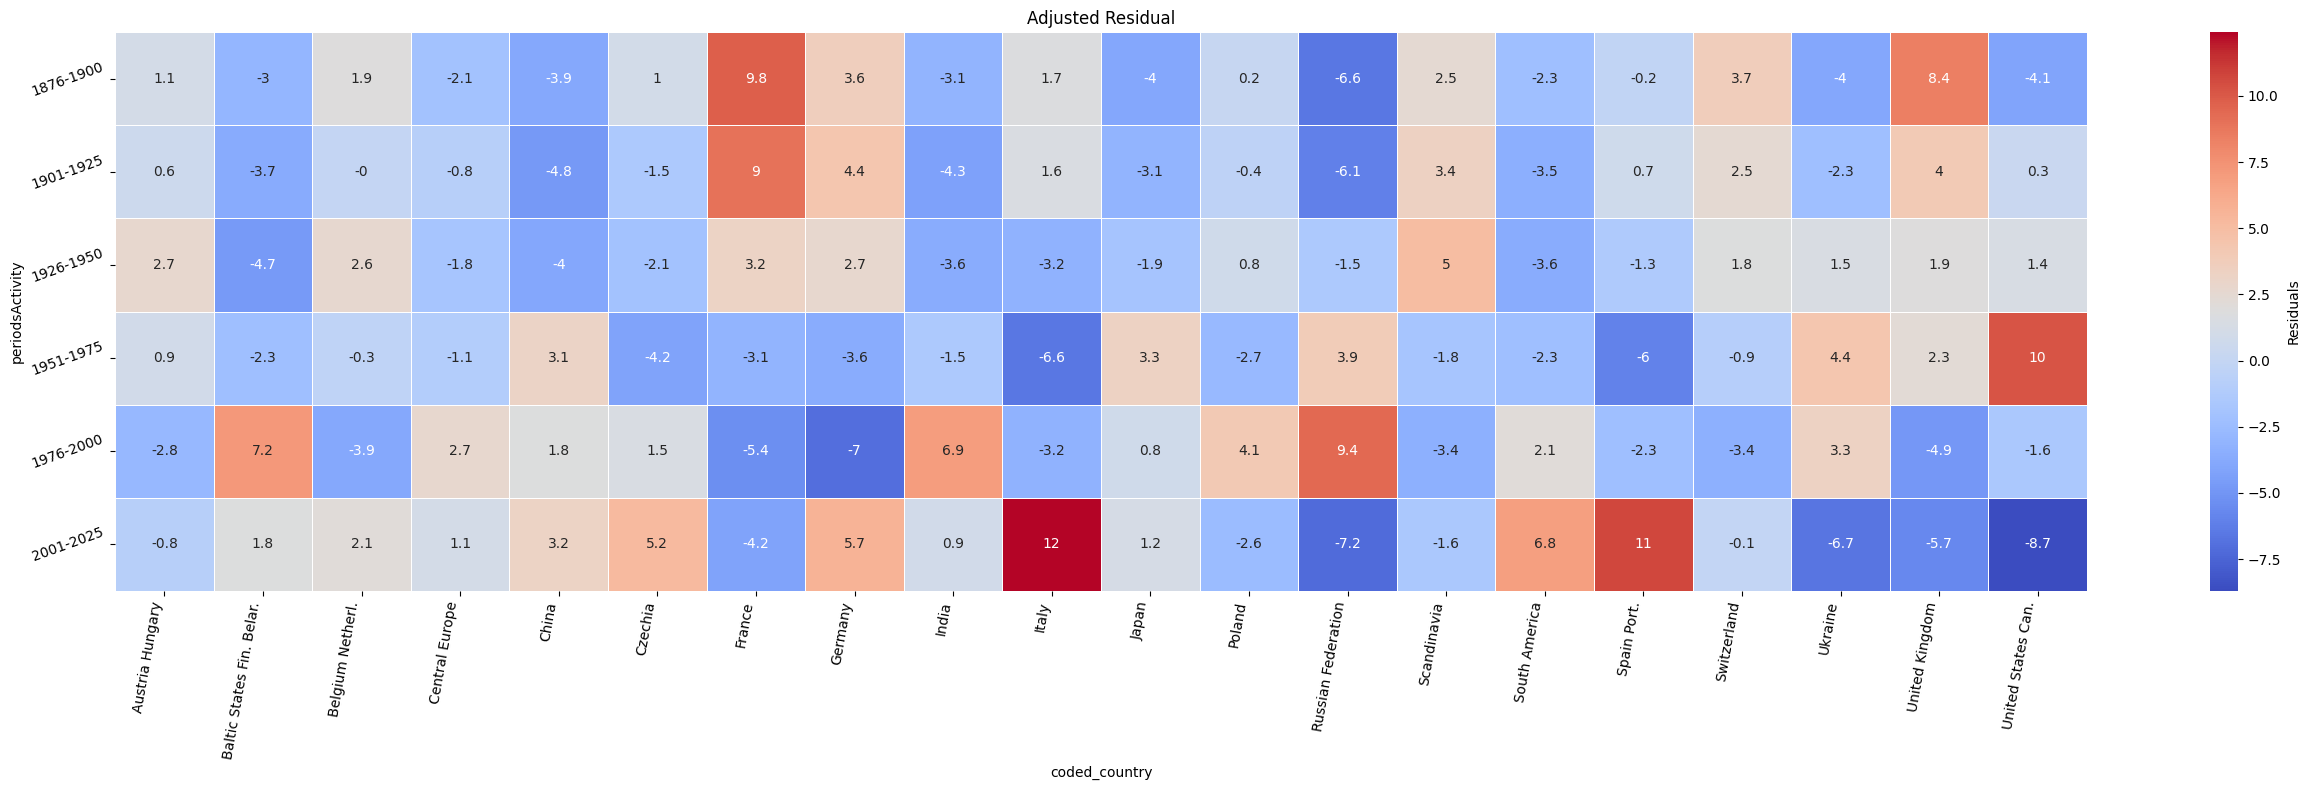

In [85]:
### Plot the residuals

# 3. Plot
fig, ax = plt.subplots(1,1,figsize=(26,8))         


# Create heatmap
sns.heatmap(
    adjusted_resids.round(1), 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax,
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')
ax.set_title("Adjusted Residual", fontsize=12)

# ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.tight_layout()
plt.show()

In [86]:
## Compare with number
per_vs_country.iloc[2:]

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.,All
periodsActivity,,,,,,,,,,,,,,,,,,,,,
1876-1900,47,22,30,25,0,53,110,180,3,61,4,46,51,26,5,17,27,16,103,87,913
1901-1925,67,35,33,52,1,60,144,277,3,90,17,66,107,41,5,31,32,45,106,204,1416
1926-1950,123,55,69,74,14,92,144,387,15,88,40,116,259,68,13,35,43,111,134,335,2215
1951-1975,219,179,107,178,100,184,199,650,63,165,143,195,675,69,51,42,64,260,276,876,4695
1976-2000,257,392,117,307,124,360,262,868,162,314,168,386,1054,88,112,109,73,338,276,908,6675
2001-2025,132,159,91,140,73,220,114,598,56,317,86,127,281,45,87,138,47,69,101,294,3175
All,875,866,480,799,315,1005,1115,3158,306,1128,459,990,2458,377,277,381,314,851,1120,2769,20043


## Bivariate analysis genders

In [87]:
gender_vs_country=pd.crosstab(df_pa.gender, df_pa.coded_country, margins=True)
gender_vs_country

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.,All
gender,,,,,,,,,,,,,,,,,,,,,
female,79,54,29,72,30,62,81,147,25,98,6,72,124,28,54,68,10,60,93,299,1491
male,796,812,451,727,285,943,1034,3011,281,1030,453,918,2334,349,223,313,304,791,1027,2470,18552
All,875,866,480,799,315,1005,1115,3158,306,1128,459,990,2458,377,277,381,314,851,1120,2769,20043


In [89]:
### Take the margins away
observed = gender_vs_country.iloc[:-1, :-1 ]
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(observed)
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 271.0129857787174 , dof : 19
p-value : 1.6719947361070301e-46


In [90]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(observed, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.11628231979307295


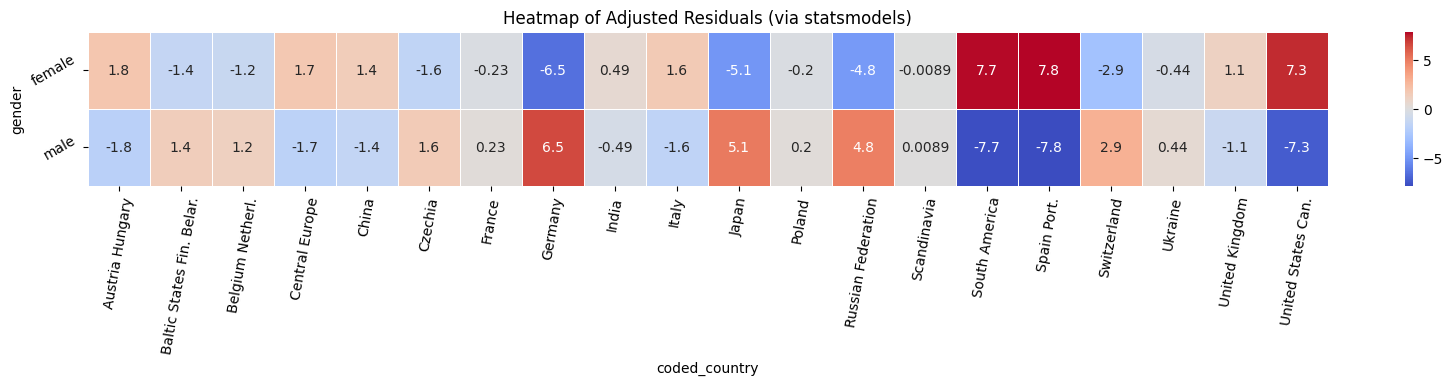

In [92]:
# 1. Create the Table object directly from your data
table = sm.stats.Table(observed)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(20,2))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()


We can observe that women are more present in some countries. The difference is statistically relevant although weak: Cramer's V = 0.116

## Bivariate analysis genders+generations vs countrys

In [93]:
def code_gender_period(gender: str):
    if gender == 'female':
        output='f'
    else:
        output='m'
    return output    

In [94]:
df_pa['per_gender']= df_pa.apply(lambda x: x.periodsActivity +'_'+ code_gender_period(x.gender), axis=1)
df_pa.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,per_gender
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA,France,1831,1826-1850,1826-1850_m
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,Germany,1827,1826-1850,1826-1850_m


In [95]:
per_gender_vs_country=pd.crosstab(df_pa.per_gender, df_pa.coded_country, margins=True)
per_gender_vs_country.iloc[6:]

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.,All
per_gender,,,,,,,,,,,,,,,,,,,,,
1901-1925_f,4,0,0,2,0,1,1,3,0,0,0,2,4,4,0,0,0,2,11,29,63
1901-1925_m,63,35,33,50,1,59,143,274,3,90,17,64,103,37,5,31,32,43,95,175,1353
1926-1950_f,16,1,5,4,0,5,17,18,1,10,0,6,18,3,2,3,0,5,12,48,174
1926-1950_m,107,54,64,70,14,87,127,369,14,78,40,110,241,65,11,32,43,106,122,287,2041
1951-1975_f,23,7,2,16,11,7,16,26,4,13,1,19,35,4,9,9,3,13,18,72,308
1951-1975_m,196,172,105,162,89,177,183,624,59,152,142,176,640,65,42,33,61,247,258,804,4387
1976-2000_f,18,25,7,27,9,23,29,29,9,20,2,36,38,7,17,13,1,29,23,71,433
1976-2000_m,239,367,110,280,115,337,233,839,153,294,166,350,1016,81,95,96,72,309,253,837,6242
2001-2025_f,18,21,14,23,10,25,18,71,10,54,3,9,27,10,26,43,6,11,18,70,487


In [97]:
### Only mor recent periods
observed = per_gender_vs_country.iloc[6:-1, :-1 ]

In [99]:
### For significant chi-2 test minimal number in each cell of expected:5
# bias in the results
statistic, p, dof, expected = stats.chi2_contingency(observed)
dfe = pd.DataFrame(expected).round(0)
dfe.index = observed.index
dfe.columns = observed.columns
dfe

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.
per_gender,,,,,,,,,,,,,,,,,,,,
1901-1925_f,3.0,3.0,1.0,3.0,1.0,3.0,3.0,10.0,1.0,3.0,2.0,3.0,8.0,1.0,1.0,1.0,1.0,3.0,3.0,9.0
1901-1925_m,59.0,61.0,31.0,56.0,23.0,68.0,64.0,207.0,22.0,73.0,34.0,66.0,177.0,23.0,20.0,26.0,19.0,61.0,66.0,195.0
1926-1950_f,8.0,8.0,4.0,7.0,3.0,9.0,8.0,27.0,3.0,9.0,4.0,9.0,23.0,3.0,3.0,3.0,2.0,8.0,9.0,25.0
1926-1950_m,90.0,92.0,47.0,84.0,35.0,103.0,97.0,312.0,34.0,109.0,51.0,100.0,267.0,35.0,30.0,40.0,29.0,92.0,100.0,294.0
1951-1975_f,14.0,14.0,7.0,13.0,5.0,16.0,15.0,47.0,5.0,17.0,8.0,15.0,40.0,5.0,5.0,6.0,4.0,14.0,15.0,44.0
1951-1975_m,193.0,198.0,101.0,181.0,75.0,221.0,208.0,671.0,72.0,235.0,110.0,215.0,573.0,75.0,65.0,86.0,63.0,199.0,216.0,632.0
1976-2000_f,19.0,20.0,10.0,18.0,7.0,22.0,21.0,66.0,7.0,23.0,11.0,21.0,57.0,7.0,6.0,8.0,6.0,20.0,21.0,62.0
1976-2000_m,274.0,282.0,143.0,258.0,107.0,315.0,296.0,955.0,103.0,334.0,156.0,306.0,816.0,107.0,92.0,122.0,89.0,283.0,307.0,899.0
2001-2025_f,21.0,22.0,11.0,20.0,8.0,25.0,23.0,74.0,8.0,26.0,12.0,24.0,64.0,8.0,7.0,10.0,7.0,22.0,24.0,70.0


In [100]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 1721.48811560484 , dof : 171
p-value : 5.505812525001499e-254


In [101]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(observed, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.10258446614463909


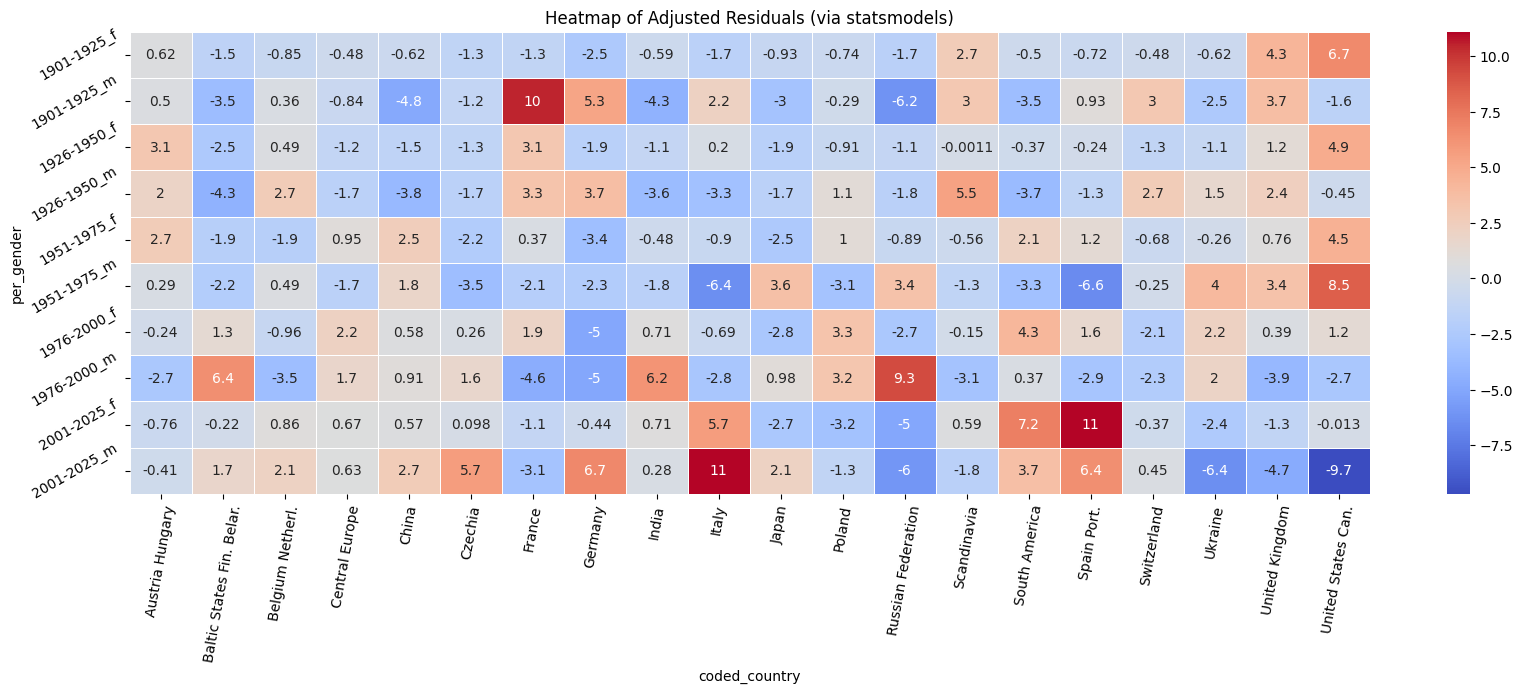

In [102]:
# 1. Create the Table object directly from your data
table = sm.stats.Table(observed)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(20,6))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()


In [104]:
dfs = df_pa[(df_pa.per_gender.isin(['2001-2025_f']))&(df_pa.coded_country.isin(['South America', 'Spain Port.']))]
print(len(dfs))

69


In [105]:
dfs.head(10)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,per_gender
16971,http://www.wikidata.org/entity/Q121890944,Isabel Hawkins,1958,female,Córdoba,POINT (-64.183333 -31.416667),http://www.wikidata.org/entity/Q44210,1951-1960,15,South America,AR,Argentina,Argentina,ARG,South America,2003,2001-2025,2001-2025_f
17366,http://www.wikidata.org/entity/Q3442245,Rosaly Lopes,1957,female,Rio de Janeiro,POINT (-43.205555 -22.911111),http://www.wikidata.org/entity/Q8678,1951-1960,15,South America,BR,Brasil,Brazil,BRA,South America,2002,2001-2025,2001-2025_f
18248,http://www.wikidata.org/entity/Q61718357,María Teresa Dova,1959,female,Alberti,POINT (-60.266667 -35.016667),http://www.wikidata.org/entity/Q940887,1951-1960,15,South America,AR,Argentina,Argentina,ARG,South America,2004,2001-2025,2001-2025_f
18269,http://www.wikidata.org/entity/Q19812690,Josefa Masegosa Gallego,1957,female,Oria,POINT (-2.292294 37.483965),http://www.wikidata.org/entity/Q1444097,1951-1960,19,Southern Europe,ES,España,Spain,ESP,Spain Port.,2002,2001-2025,2001-2025_f
18275,http://www.wikidata.org/entity/Q19766208,Teresa Rodrigo Anoro,1956,female,Almacelles,POINT (0.437057 41.731689),http://www.wikidata.org/entity/Q1626921,1951-1960,19,Southern Europe,ES,España,Spain,ESP,Spain Port.,2001,2001-2025,2001-2025_f
18459,http://www.wikidata.org/entity/Q62072509,Judith Desimoni,1956,female,Olavarría,POINT (-60.333333 -36.9),http://www.wikidata.org/entity/Q1004149,1951-1960,15,South America,AR,Argentina,Argentina,ARG,South America,2001,2001-2025,2001-2025_f
18524,http://www.wikidata.org/entity/Q6757087,Marcia Barbosa,1960,female,Rio de Janeiro,POINT (-43.205555 -22.911111),http://www.wikidata.org/entity/Q8678,1951-1960,15,South America,BR,Brasil,Brazil,BRA,South America,2005,2001-2025,2001-2025_f
18649,http://www.wikidata.org/entity/Q55704831,Sonia Guimarães,1957,female,Brotas,POINT (-48.126944 -22.283889),http://www.wikidata.org/entity/Q1648408,1951-1960,15,South America,BR,Brasil,Brazil,BRA,South America,2002,2001-2025,2001-2025_f
19148,http://www.wikidata.org/entity/Q60758204,María Luisa Sarsa,1968,female,Zaragoza,POINT (-0.883333 41.65),http://www.wikidata.org/entity/Q10305,1961-1970,19,Southern Europe,ES,España,Spain,ESP,Spain Port.,2013,2001-2025,2001-2025_f
19156,http://www.wikidata.org/entity/Q16843449,Gabriela González,1965,female,Córdoba,POINT (-64.183333 -31.416667),http://www.wikidata.org/entity/Q44210,1961-1970,15,South America,AR,Argentina,Argentina,ARG,South America,2010,2001-2025,2001-2025_f


### Inspected persons

* [Josefa Masegosa Gallego](http://www.wikidata.org/entity/Q19812690) (Spain)
* [Judith Desimoni](http://www.wikidata.org/entity/Q62072509) (Argentina)